# ISTA — Iterative Shrinkage-Thresholding Algorithm

## The LASSO Problem

**LASSO** (Tibshirani, 1996) solves the $\ell^1$-penalized least-squares problem:
$$\min_{x \in \mathbb{R}^p} \underbrace{\frac{1}{2}\|Ax - y\|^2}_{\text{data fidelity}} + \lambda \underbrace{\|x\|_1}_{\text{sparsity}}$$

where $A \in \mathbb{R}^{n \times p}$ is a measurement matrix, $y \in \mathbb{R}^n$ are observations, and $\lambda > 0$ controls the sparsity level.

## ISTA as Proximal Gradient Descent

**ISTA** (Daubechies et al., 2004) is the **proximal gradient descent** algorithm applied to the LASSO. At each step:
$$x^{(k+1)} = \mathbf{prox}_{\tau\lambda\|\cdot\|_1}\left(x^{(k)} - \tau A^T(Ax^{(k)} - y)\right)$$

The proximal operator of $\|\cdot\|_1$ is the **soft-thresholding** (shrinkage) operator:
$$\mathbf{prox}_{t\|\cdot\|_1}(u)_i = \text{sign}(u_i) \max(|u_i| - t, 0) =: S_t(u_i)$$

## Convergence Rate

ISTA converges at rate $O(1/k)$ in function value for step size $\tau \leq 1/L$ (where $L = \|A\|^2$ is the Lipschitz constant of $\nabla \frac{1}{2}\|Ax-y\|^2$). **FISTA** (Beck & Teboulle, 2009) accelerates this to $O(1/k^2)$ using Nesterov momentum.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, IntSlider

### Soft-thresholding operator

The soft-thresholding operator $S_t(u) = \text{sign}(u) \max(|u| - t, 0)$ is the building block of ISTA. It **shrinks** coefficients toward zero by $t$ and sets to zero those smaller than $t$.

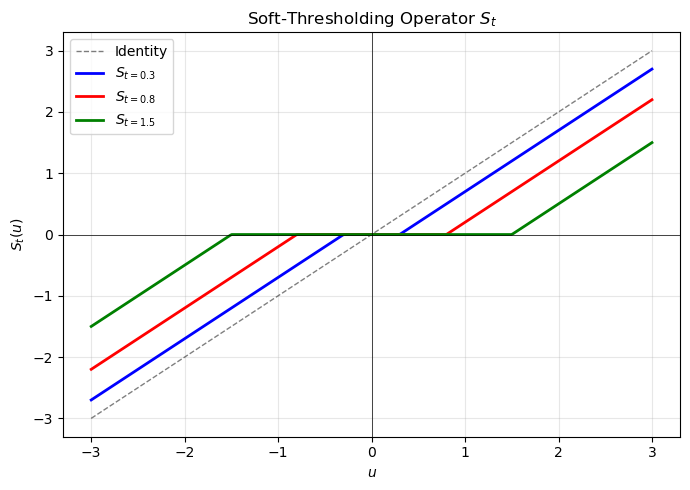

In [2]:
def soft_threshold(u, t):
    return np.sign(u) * np.maximum(np.abs(u) - t, 0)

u_grid = np.linspace(-3, 3, 400)
t_vals = [0.3, 0.8, 1.5]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(u_grid, u_grid, 'k--', lw=1, alpha=0.5, label='Identity')
for t, col in zip(t_vals, ['blue', 'red', 'green']):
    ax.plot(u_grid, soft_threshold(u_grid, t), color=col, lw=2, label=f'$S_{{t={t}}}$')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('$u$'); ax.set_ylabel('$S_t(u)$')
ax.set_title('Soft-Thresholding Operator $S_t$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('soft_thresh.png', dpi=100, bbox_inches='tight'); plt.show()

### 2D LASSO geometry

With a dictionary $A = [a_1, a_2]$ (two atoms), the LASSO objective has a distinctive geometry:
- Level sets of the data term $\frac{1}{2}\|Ax-y\|^2$: ellipses (axis tilted by $A$)
- Level sets of $\|x\|_1$: diamonds (ℓ¹ ball)

The solution tends to lie at a **corner** of the ℓ¹ ball — the origin of sparsity promotion.

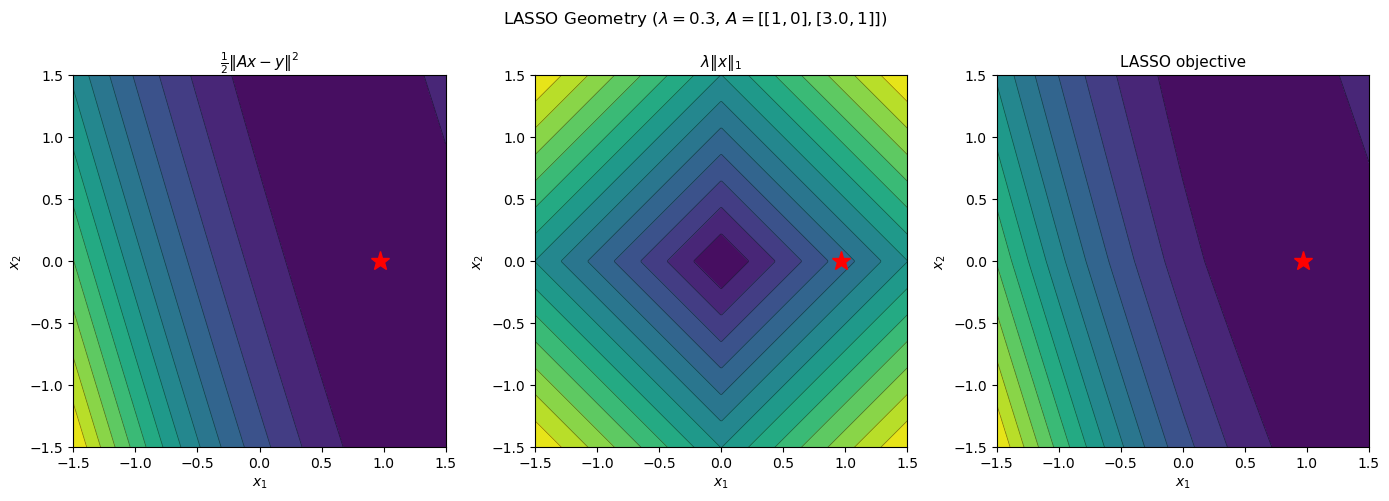

In [3]:
rng = np.random.default_rng(42)
eta = 3.0
A2 = np.array([[1.0, 0.0],
               [eta, 1.0]])
x0_true = np.array([1.0, 0.0])
y2 = A2 @ x0_true
lam = 0.3

q = 300
a_val = 1.5
t1 = np.linspace(-a_val, a_val, q)
T1, T2 = np.meshgrid(t1, t1)
Z = np.stack([T1.ravel(), T2.ravel()], axis=1)

residuals = (Z @ A2.T - y2[None, :])
F_data = 0.5 * np.sum(residuals**2, axis=1)
F_l1 = lam * np.sum(np.abs(Z), axis=1)
F_total = F_data + F_l1

F_data = F_data.reshape(q, q)
F_l1 = F_l1.reshape(q, q)
F_total = F_total.reshape(q, q)

# Find minimizer
idx = np.unravel_index(F_total.argmin(), F_total.shape)
x_opt = np.array([t1[idx[1]], t1[idx[0]]])

r = 15
levels = np.linspace(0, 1, r)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, F, title in zip(axes, [F_data, F_l1, F_total],
                          [r'$\frac{1}{2}\|Ax-y\|^2$', r'$\lambda\|x\|_1$', r'LASSO objective']):
    F_norm = (F - F.min()) / (F.max() - F.min())
    ax.contourf(T1, T2, F_norm, levels=levels, cmap='viridis')
    ax.contour(T1, T2, F_norm, levels=levels, colors='k', linewidths=0.5, alpha=0.5)
    ax.plot(*x_opt, 'r*', ms=14)
    ax.set_title(title, fontsize=11); ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.suptitle(f'LASSO Geometry ($\\lambda={lam}$, $A = [[1,0],[{eta},1]]$)', fontsize=12)
plt.tight_layout(); plt.savefig('lasso_geometry.png', dpi=100, bbox_inches='tight'); plt.show()

### ISTA and FISTA implementations

We implement both algorithms and compare their convergence curves. FISTA adds a momentum step:
$$y^{(k+1)} = x^{(k+1)} + \frac{t_k - 1}{t_{k+1}}(x^{(k+1)} - x^{(k)}), \quad t_{k+1} = \frac{1 + \sqrt{1 + 4t_k^2}}{2}$$

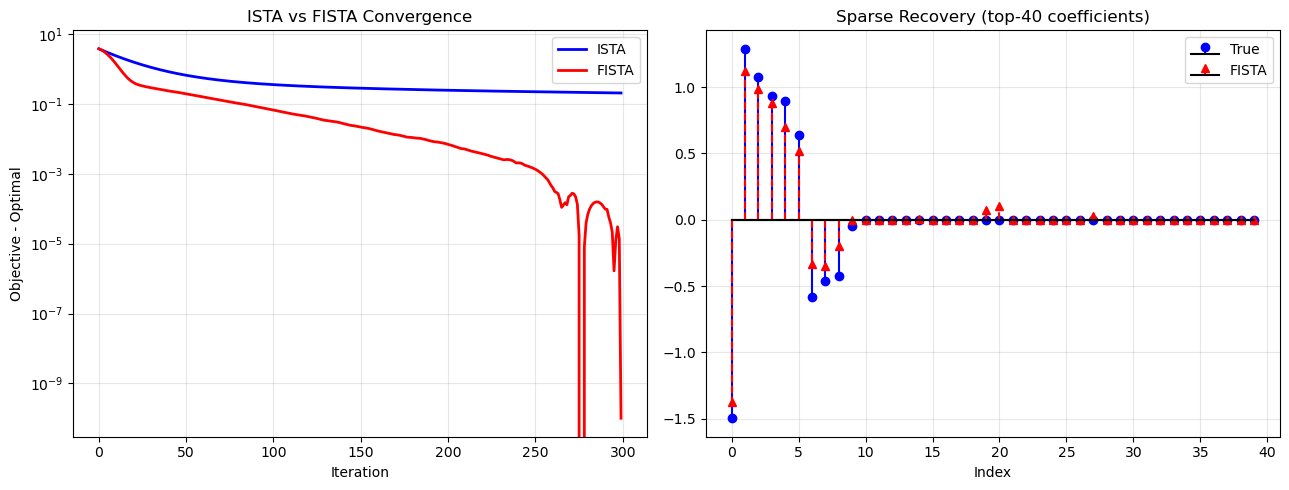

In [4]:
def ista(A, y, lam, tau=None, n_iter=500):
    p = A.shape[1]
    if tau is None:
        L = np.linalg.norm(A)**2
        tau = 1.0 / L
    x = np.zeros(p)
    loss = []
    for _ in range(n_iter):
        grad = A.T @ (A @ x - y)
        x = soft_threshold(x - tau * grad, tau * lam)
        loss.append(0.5 * np.linalg.norm(A @ x - y)**2 + lam * np.sum(np.abs(x)))
    return x, np.array(loss)

def fista(A, y, lam, tau=None, n_iter=500):
    p = A.shape[1]
    if tau is None:
        L = np.linalg.norm(A)**2
        tau = 1.0 / L
    x = np.zeros(p); z = x.copy()
    t = 1.0
    loss = []
    for _ in range(n_iter):
        x_prev = x.copy()
        grad = A.T @ (A @ z - y)
        x = soft_threshold(z - tau * grad, tau * lam)
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = x + (t - 1) / t_new * (x - x_prev)
        t = t_new
        loss.append(0.5 * np.linalg.norm(A @ x - y)**2 + lam * np.sum(np.abs(x)))
    return x, np.array(loss)

# Test problem: compressed sensing
rng2 = np.random.default_rng(7)
n_obs, p_dim = 50, 200
A_cs = rng2.standard_normal((n_obs, p_dim)) / np.sqrt(n_obs)
x_true = np.zeros(p_dim)
idx_nz = rng2.choice(p_dim, 10, replace=False)
x_true[idx_nz] = rng2.standard_normal(10)
y_obs = A_cs @ x_true + 0.05 * rng2.standard_normal(n_obs)
lam_cs = 0.05

x_ista, loss_ista = ista(A_cs, y_obs, lam_cs, n_iter=300)
x_fista, loss_fista = fista(A_cs, y_obs, lam_cs, n_iter=300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
loss_min = min(loss_ista[-1], loss_fista[-1])
axes[0].semilogy(loss_ista - loss_min + 1e-10, 'b-', lw=2, label='ISTA')
axes[0].semilogy(loss_fista - loss_min + 1e-10, 'r-', lw=2, label='FISTA')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Objective - Optimal')
axes[0].set_title('ISTA vs FISTA Convergence'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

idx_sorted = np.argsort(np.abs(x_true))[::-1][:40]
axes[1].stem(x_true[idx_sorted], linefmt='b-', markerfmt='bo', basefmt='k-', label='True')
axes[1].stem(x_fista[idx_sorted], linefmt='r--', markerfmt='r^', basefmt='k-', label='FISTA')
axes[1].set_title('Sparse Recovery (top-40 coefficients)')
axes[1].legend(); axes[1].set_xlabel('Index')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig('ista_convergence.png', dpi=100, bbox_inches='tight'); plt.show()

### LASSO regularization path

As $\lambda$ decreases from $\lambda_{\max} = \|A^T y\|_\infty$ to 0, the solution becomes progressively less sparse. The **regularization path** traces how each coefficient enters and grows.

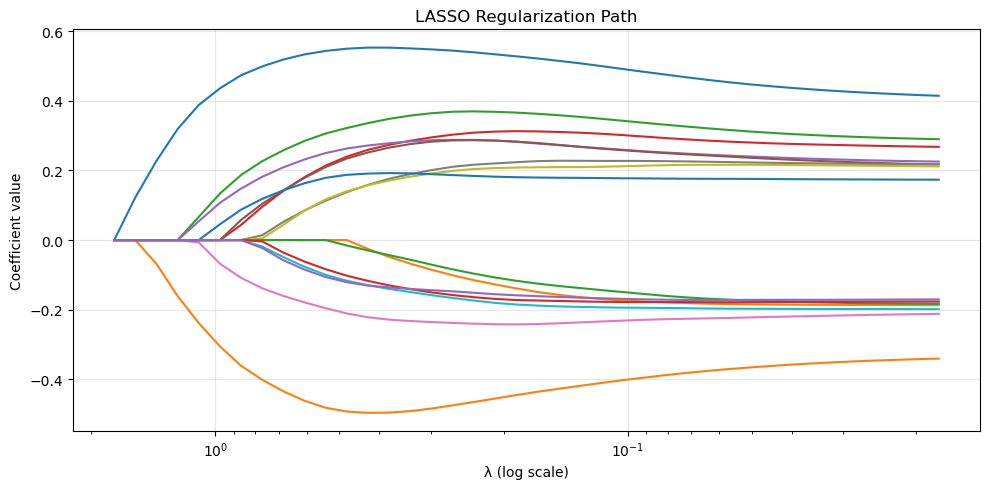

In [5]:
lam_max = np.max(np.abs(A_cs.T @ y_obs))
lam_list = np.logspace(np.log10(lam_max), np.log10(lam_max * 0.01), 40)
path = []
x_warm = np.zeros(p_dim)
for lam_k in lam_list:
    x_warm, _ = ista(A_cs, y_obs, lam_k, n_iter=200)
    path.append(x_warm.copy())

path = np.array(path)  # (n_lam, p_dim)
# Show top-k trajectories
top_k = np.argsort(np.max(np.abs(path), axis=0))[::-1][:15]

plt.figure(figsize=(10, 5))
for j in top_k:
    plt.plot(lam_list, path[:, j], lw=1.5)
plt.xscale('log'); plt.gca().invert_xaxis()
plt.xlabel('λ (log scale)'); plt.ylabel('Coefficient value')
plt.title('LASSO Regularization Path')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('lasso_path.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: LASSO with varying λ

In [ ]:
def show_lasso(log_lam=-1.5, n_iter=200):
    lam_i = 10**log_lam
    x_sol, loss_sol = fista(A_cs, y_obs, lam_i, n_iter=n_iter)
    nnz = np.sum(np.abs(x_sol) > 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].stem(x_true, linefmt='b-', markerfmt='bo', basefmt='k-', label='True')
    axes[0].stem(x_sol, linefmt='r--', markerfmt='r^', basefmt='k-', label=f'LASSO ({nnz} nnz)')
    axes[0].set_title(f'λ={lam_i:.4f}'); axes[0].legend()
    axes[1].semilogy(loss_sol, 'b-', lw=2)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('LASSO objective')
    axes[1].set_title('Convergence curve'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_lasso,
         log_lam=FloatLogSlider(value=-1.5, min=-2.5, max=0, step=0.1,
                                 base=10, description='λ (log)'),
         n_iter=IntSlider(min=50, max=500, step=50, value=200));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(1, 3, figsize=(14, 5))
    for ax, F, title in zip(axes, [F_data, F_l1, F_total],
                              [r'$\frac{1}{2}\|Ax-y\|^2$', r'$\lambda\|x\|_1$', r'LASSO']):
        F_norm = (F - F.min()) / (F.max() - F.min())
        ax.contourf(T1, T2, F_norm, levels=15, cmap='viridis')
        ax.contour(T1, T2, F_norm, levels=15, colors='k', linewidths=0.4, alpha=0.5)
        ax.plot(*x_opt, 'r*', ms=14)
        ax.set_title(title, fontsize=11); ax.set_aspect('equal')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- ISTA is **proximal gradient descent** on the LASSO objective, with the soft-threshold operator as the proximal step.
- FISTA achieves the optimal $O(1/k^2)$ rate for non-smooth convex minimization by adding Nesterov momentum.
- The ℓ¹ penalty promotes **sparsity** by concentrating solutions at corners of the ℓ¹ ball.
- The step size $\tau \leq 1/\|A\|^2$ is the stability condition; the larger $\|A\|$, the smaller the allowed step.

## Bibliography

- I. Daubechies, M. Defrise & C. De Mol, *An iterative thresholding algorithm for linear inverse problems*, Comm. Pure Appl. Math. 57, 2004.
- A. Beck & M. Teboulle, *A fast iterative shrinkage-thresholding algorithm for linear inverse problems*, SIAM J. Imaging Sci. 2(1), 2009.
- R. Tibshirani, *Regression shrinkage and selection via the lasso*, JRSS-B 58(1), 1996.